# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [2]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

# Separate features and target
X = df.drop(columns="class")
y = df["class"]

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [7]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [9]:
df.dropna(inplace=True)

print("Shape AFTER  cleaning:", df.shape)
print(f"Rows removed: {48842 - df.shape[0]}")
print(df.isna().sum())

Shape AFTER  cleaning: (45222, 15)
Rows removed: 3620
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = df.drop(columns="class")
y = df["class"]

for col in X.columns:
    if str(X[col].dtype) == "category" or X[col].dtype == "object":
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"Encoded: {col}")

print()
print("Encoding done")
print(X.head())

Encoded: workclass
Encoded: education
Encoded: marital-status
Encoded: occupation
Encoded: relationship
Encoded: race
Encoded: sex
Encoded: native-country

Encoding done
   age  workclass  fnlwgt  education  education-num  marital-status  \
0   25          2  226802          1              7               4   
1   38          2   89814         11              9               2   
2   28          1  336951          7             12               2   
3   44          2  160323         15             10               2   
5   34          2  198693          0              6               4   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           6             3     2    1             0             0   
1           4             0     4    1             0             0   
2          10             0     4    1             0             0   
3           6             0     2    1          7688             0   
5           7             1     4    1             0 

In [11]:
y = (y.astype(str).str.strip() == ">50K").astype(int)

print("Target after conversion:")
print(y.value_counts())
print()
print("0 = earns <=50K")
print("1 = earns  >50K")

Target after conversion:
class
0    34014
1    11208
Name: count, dtype: int64

0 = earns <=50K
1 = earns  >50K


In [13]:
X = X.values.astype(np.float32)
y = y.values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Training set   : {X_train.shape}")
print(f"Validation set : {X_val.shape}")
print(f"Test set       : {X_test.shape}")

Training set   : (31655, 14)
Validation set : (6783, 14)
Test set       : (6784, 14)


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val  = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Scaling done")
print()
print("Example — first row of X_train after scaling:")
print(X_train[0])

Scaling done

Example — first row of X_train after scaling:
[ 0.33639526 -0.21803665 -0.5162542   0.44399783  1.5102029  -1.7153839
 -0.740302   -0.25640363  0.38407078 -1.4432182  -0.14805736 -0.21840025
  0.74727875  0.26588708]


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_model():
    model = Sequential([
        Input(shape=(14,)),

        Dense(64, activation='relu'),

        Dense(32, activation='relu'),

        Dense(1, activation='sigmoid')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)



---




## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


### Stochastic Gradient Descent (SGD)

In [16]:
model_sgd = build_model()

model_sgd.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7535 - loss: 0.5133 - val_accuracy: 0.8138 - val_loss: 0.4010
Epoch 2/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8244 - loss: 0.3827 - val_accuracy: 0.8271 - val_loss: 0.3719
Epoch 3/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8351 - loss: 0.3589 - val_accuracy: 0.8340 - val_loss: 0.3537
Epoch 4/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8428 - loss: 0.3394 - val_accuracy: 0.8381 - val_loss: 0.3459
Epoch 5/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8417 - loss: 0.3345 - val_accuracy: 0.8400 - val_loss: 0.3416
Epoch 6/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8437 - loss: 0.3332 - val_accuracy: 0.8383 - val_loss: 0.3396
Epoch 7/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8449 - loss: 0.3337 - val_accuracy: 0.8387 - val_loss: 0.3386
Epoch 8/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8474 - loss: 0.3283 - val_accuracy: 0.

### SGD with Momentum

In [17]:
from tensorflow.keras.optimizers import SGD

model_sgd_mom = build_model()

model_sgd_mom.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd_mom = model_sgd_mom.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8115 - loss: 0.4036 - val_accuracy: 0.8411 - val_loss: 0.3387
Epoch 2/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8406 - loss: 0.3356 - val_accuracy: 0.8397 - val_loss: 0.3363
Epoch 3/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8463 - loss: 0.3307 - val_accuracy: 0.8406 - val_loss: 0.3363
Epoch 4/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8479 - loss: 0.3253 - val_accuracy: 0.8405 - val_loss: 0.3341
Epoch 5/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8470 - loss: 0.3243 - val_accuracy: 0.8343 - val_loss: 0.3365
Epoch 6/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8488 - loss: 0.3203 - val_accuracy: 0.8371 - val_loss: 0.3361
Epoch 7/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8484 - loss: 0.3249 - val_accuracy: 0.8415 - val_loss: 0.3322
Epoch 8/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8497 - loss: 0.3199 - val_accuracy: 0.

### Adam

In [18]:
model_adam = build_model()

model_adam.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8128 - loss: 0.4079 - val_accuracy: 0.8380 - val_loss: 0.3419
Epoch 2/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8410 - loss: 0.3371 - val_accuracy: 0.8378 - val_loss: 0.3417
Epoch 3/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8503 - loss: 0.3213 - val_accuracy: 0.8380 - val_loss: 0.3387
Epoch 4/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8488 - loss: 0.3240 - val_accuracy: 0.8423 - val_loss: 0.3345
Epoch 5/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8475 - loss: 0.3257 - val_accuracy: 0.8449 - val_loss: 0.3321
Epoch 6/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8475 - loss: 0.3219 - val_accuracy: 0.8427 - val_loss: 0.3325
Epoch 7/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8499 - loss: 0.3202 - val_accuracy: 0.8397 - val_loss: 0.3319
Epoch 8/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8520 - loss: 0.3170 - val_accuracy: 0.

### Comparison

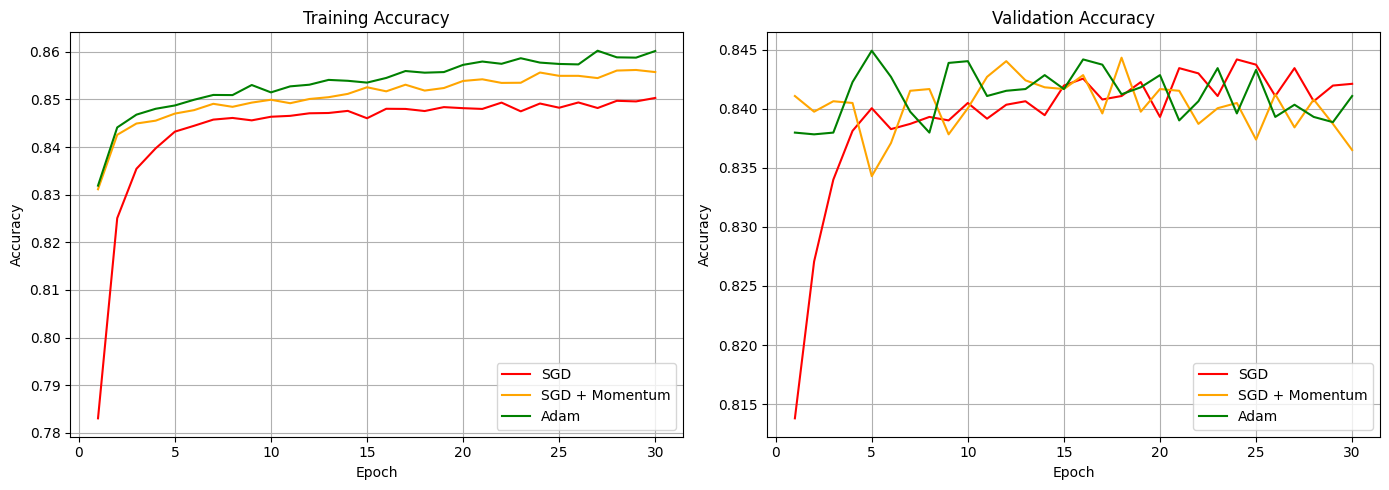

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, 31)

plt.figure(figsize=(14, 5))

# --- Training Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_sgd.history['accuracy'],     label='SGD',             color='red')
plt.plot(epochs, history_sgd_mom.history['accuracy'], label='SGD + Momentum',  color='orange')
plt.plot(epochs, history_adam.history['accuracy'],    label='Adam',            color='green')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_sgd.history['val_accuracy'],     label='SGD',            color='red')
plt.plot(epochs, history_sgd_mom.history['val_accuracy'], label='SGD + Momentum', color='orange')
plt.plot(epochs, history_adam.history['val_accuracy'],    label='Adam',           color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
loss_sgd,     acc_sgd     = model_sgd.evaluate(X_test, y_test, verbose=0)
loss_sgd_mom, acc_sgd_mom = model_sgd_mom.evaluate(X_test, y_test, verbose=0)
loss_adam,    acc_adam    = model_adam.evaluate(X_test, y_test, verbose=0)

train_sgd     = history_sgd.history['accuracy'][-1]
train_sgd_mom = history_sgd_mom.history['accuracy'][-1]
train_adam    = history_adam.history['accuracy'][-1]

val_sgd     = history_sgd.history['val_accuracy'][-1]
val_sgd_mom = history_sgd_mom.history['val_accuracy'][-1]
val_adam    = history_adam.history['val_accuracy'][-1]

print("=" * 55)
print(f"{'Optimizer':<20} {'Train':>10} {'Val':>10} {'Test':>10}")
print("=" * 55)
print(f"{'SGD':<20} {train_sgd:>10.4f} {val_sgd:>10.4f} {acc_sgd:>10.4f}")
print(f"{'SGD + Momentum':<20} {train_sgd_mom:>10.4f} {val_sgd_mom:>10.4f} {acc_sgd_mom:>10.4f}")
print(f"{'Adam':<20} {train_adam:>10.4f} {val_adam:>10.4f} {acc_adam:>10.4f}")
print("=" * 55)

Optimizer                 Train        Val       Test
SGD                      0.8503     0.8421     0.8468
SGD + Momentum           0.8558     0.8365     0.8461
Adam                     0.8602     0.8411     0.8443


**Why does Adam perform better in training?**

Adam automatically adjusts the learning rate for each parameter — it learns fast where needed and slows down where needed. Plain SGD uses the same fixed learning rate for everything


|                      | SGD        | SGD + Momentum    | Adam       |
| -------------------- | ---------- | ----------------- | ---------- |
| Convergence speed    |  Slowest |  Medium         |  Fastest |
| Final train accuracy | Lowest     | Medium            | Highest    |
| Generalization (val) |  Stable   |  Slightly worse |  Good     |



---



## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

### **We will train 10 epochs only because batch=1 is very slow**

In [23]:
import time

model_bs1 = build_model()
model_bs1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs1 = model_bs1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=1,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs1 = time.time() - start
print(f"\nTraining time: {time_bs1:.1f} seconds")

Epoch 1/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step - accuracy: 0.8228 - loss: 0.3699 - val_accuracy: 0.8442 - val_loss: 0.3404
Epoch 2/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.8477 - loss: 0.3302 - val_accuracy: 0.8396 - val_loss: 0.3354
Epoch 3/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step - accuracy: 0.8434 - loss: 0.3362 - val_accuracy: 0.8417 - val_loss: 0.3297
Epoch 4/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.8479 - loss: 0.3286 - val_accuracy: 0.8403 - val_loss: 0.3343
Epoch 5/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.8495 - loss: 0.3269 - val_accuracy: 0.8411 - val_loss: 0.3306
Epoch 6/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.8553 - loss: 0.3152 - val_accuracy: 0.8461 - val_loss: 0.3310
Epoch 7/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.8484 - loss: 0.3236 - val_accuracy: 0.8439 - val_loss: 0.3315
Epoch 8/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step - accuracy: 

In [25]:
model_bs32 = build_model()
model_bs32.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs32 = model_bs32.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs32 = time.time() - start
print(f"Batch size 32 done")
print(f"Training time   : {time_bs32:.1f} seconds")
print(f"Final Train Acc : {history_bs32.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_bs32.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7995 - loss: 0.4190 - val_accuracy: 0.8375 - val_loss: 0.3410
Epoch 2/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8410 - loss: 0.3362 - val_accuracy: 0.8418 - val_loss: 0.3375
Epoch 3/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8485 - loss: 0.3257 - val_accuracy: 0.8397 - val_loss: 0.3346
Epoch 4/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8455 - loss: 0.3257 - val_accuracy: 0.8436 - val_loss: 0.3327
Epoch 5/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8481 - loss: 0.3257 - val_accuracy: 0.8399 - val_loss: 0.3350
Epoch 6/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8517 - loss: 0.3180 - val_accuracy: 0.8359 - val_loss: 0.3339
Epoch 7/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8460 - loss: 0.3247 - val_accuracy: 0.8436 - val_loss: 0.3303
Epoch 8/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8494 - loss: 0.3177 - val_accuracy: 0.

In [27]:
model_bs128 = build_model()
model_bs128.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs128 = model_bs128.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs128 = time.time() - start
print(f"Batch size 128 done")
print(f"Training time   : {time_bs128:.1f} seconds")
print(f"Final Train Acc : {history_bs128.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_bs128.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7916 - loss: 0.4487 - val_accuracy: 0.8337 - val_loss: 0.3506
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8418 - loss: 0.3356 - val_accuracy: 0.8395 - val_loss: 0.3377
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8459 - loss: 0.3304 - val_accuracy: 0.8397 - val_loss: 0.3388
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8514 - loss: 0.3202 - val_accuracy: 0.8402 - val_loss: 0.3352
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.3260 - val_accuracy: 0.8402 - val_loss: 0.3344
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8526 - loss: 0.3180 - val_accuracy: 0.8427 - val_loss: 0.3335
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8479 - loss: 0.3191 - val_accuracy: 0.8434 - val_loss: 0.3345
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8491 - loss: 0.3223 - val_accuracy: 0.

In [29]:
model_bs1024 = build_model()
model_bs1024.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs1024 = model_bs1024.fit(
    X_train, y_train,
    epochs=10,
    batch_size=1024,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs1024 = time.time() - start
print(f"Batch size 1024 done")
print(f"Training time   : {time_bs1024:.1f} seconds")
print(f"Final Train Acc : {history_bs1024.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_bs1024.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6975 - loss: 0.5933 - val_accuracy: 0.7914 - val_loss: 0.4515
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8038 - loss: 0.4324 - val_accuracy: 0.8142 - val_loss: 0.4042
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8201 - loss: 0.3942 - val_accuracy: 0.8252 - val_loss: 0.3856
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8306 - loss: 0.3724 - val_accuracy: 0.8294 - val_loss: 0.3686
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8313 - loss: 0.3577 - val_accuracy: 0.8338 - val_loss: 0.3571
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8391 - loss: 0.3471 - val_accuracy: 0.8381 - val_loss: 0.3495
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8429 - loss: 0.3356 - val_accuracy: 0.8392 - val_loss: 0.3451
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8414 - loss: 0.3367 - val_accuracy: 0.8381 - val_loss

### Comparison

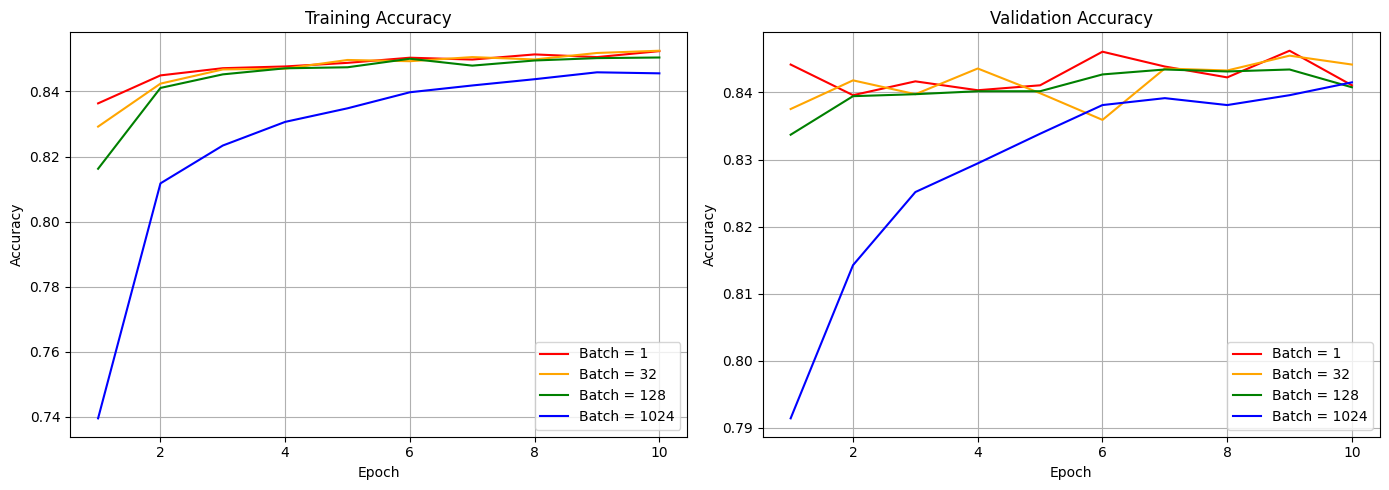

In [30]:
epochs = range(1, 11)

plt.figure(figsize=(14, 5))

# --- Training Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_bs1.history['accuracy'],    label='Batch = 1',    color='red')
plt.plot(epochs, history_bs32.history['accuracy'],   label='Batch = 32',   color='orange')
plt.plot(epochs, history_bs128.history['accuracy'],  label='Batch = 128',  color='green')
plt.plot(epochs, history_bs1024.history['accuracy'], label='Batch = 1024', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_bs1.history['val_accuracy'],    label='Batch = 1',    color='red')
plt.plot(epochs, history_bs32.history['val_accuracy'],   label='Batch = 32',   color='orange')
plt.plot(epochs, history_bs128.history['val_accuracy'],  label='Batch = 128',  color='green')
plt.plot(epochs, history_bs1024.history['val_accuracy'], label='Batch = 1024', color='blue')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
# Evaluate each model on the test set
_, acc_bs1    = model_bs1.evaluate(X_test,   y_test, verbose=0)
_, acc_bs32   = model_bs32.evaluate(X_test,  y_test, verbose=0)
_, acc_bs128  = model_bs128.evaluate(X_test, y_test, verbose=0)
_, acc_bs1024 = model_bs1024.evaluate(X_test,y_test, verbose=0)

# Get final train and val accuracy from history
train_bs1    = history_bs1.history['accuracy'][-1]
train_bs32   = history_bs32.history['accuracy'][-1]
train_bs128  = history_bs128.history['accuracy'][-1]
train_bs1024 = history_bs1024.history['accuracy'][-1]

val_bs1    = history_bs1.history['val_accuracy'][-1]
val_bs32   = history_bs32.history['val_accuracy'][-1]
val_bs128  = history_bs128.history['val_accuracy'][-1]
val_bs1024 = history_bs1024.history['val_accuracy'][-1]

# Print summary table
print("=" * 65)
print(f"{'Batch Size':<12} {'Train':>10} {'Val':>10} {'Test':>10} {'Time(s)':>10}")
print("=" * 65)
print(f"{'1':<12} {train_bs1:>10.4f} {val_bs1:>10.4f} {acc_bs1:>10.4f} {time_bs1:>10.1f}")
print(f"{'32':<12} {train_bs32:>10.4f} {val_bs32:>10.4f} {acc_bs32:>10.4f} {time_bs32:>10.1f}")
print(f"{'128':<12} {train_bs128:>10.4f} {val_bs128:>10.4f} {acc_bs128:>10.4f} {time_bs128:>10.1f}")
print(f"{'1024':<12} {train_bs1024:>10.4f} {val_bs1024:>10.4f} {acc_bs1024:>10.4f} {time_bs1024:>10.1f}")
print("=" * 65)

Batch Size        Train        Val       Test    Time(s)
1                0.8524     0.8411     0.8466      682.4
32               0.8525     0.8442     0.8471       28.8
128              0.8504     0.8408     0.8461        9.9
1024             0.8456     0.8415     0.8457        3.3


| Batch Size | Speed   | Noise       | Generalization       |
| ---------- | ------- | ----------- | -------------------- |
| 1          |  682s |  Highest  |  Good but unstable  |
| 32         |  28s   |  Moderate |  Best balance       |
| 128        |  9.9s  |  Low      |  Good               |
| 1024       |  3.3s |  Lowest   |  Needs more epochs |

Noisiest gradient updates → Batch size = 1 (one sample per update)

Best generalization → Batch size = 32 (good balance between noise and stability)



---




## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


### Training Large Model To Try Overfitting

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_large_model():
    model = Sequential([
        Input(shape=(14,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(1,   activation='sigmoid')
    ])
    return model

model_no_reg = build_large_model()
model_no_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Large model summary:")
model_no_reg.summary()

Large model summary:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 512)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,225 (704.00 KB)

 Trainable params: 180,225 (704.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_no_reg = model_no_reg.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Training done")
print(f"Final Train Acc : {history_no_reg.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_no_reg.history['val_accuracy'][-1]:.4f}")
gap = history_no_reg.history['accuracy'][-1] - history_no_reg.history['val_accuracy'][-1]
print(f"Gap (Train-Val) : {gap:.4f}  ← overfitting indicator")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8487 - loss: 0.3327 - val_accuracy: 0.8411 - val_loss: 0.3316
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8481 - loss: 0.3252 - val_accuracy: 0.8430 - val_loss: 0.3365
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8484 - loss: 0.3241 - val_accuracy: 0.8439 - val_loss: 0.3348
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8528 - loss: 0.3220 - val_accuracy: 0.8431 - val_loss: 0.3325
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8488 - loss: 0.3207 - val_accuracy: 0.8448 - val_loss: 0.3304
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8549 - loss: 0.3128 - val_accuracy: 0.8434 - val_loss: 0.3378
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8519 - loss: 0.3142 - val_accuracy: 0.8434 - val_loss: 0.3300
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8541 - loss: 0.3093 - val_accuracy: 0.

In [35]:
from tensorflow.keras import regularizers

def build_large_model_l2():
    model = Sequential([
        Input(shape=(14,)),
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(1,   activation='sigmoid')
    ])
    return model

model_l2 = build_large_model_l2()
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("L2 Training done")
print(f"Final Train Acc : {history_l2.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_l2.history['val_accuracy'][-1]:.4f}")
gap = history_l2.history['accuracy'][-1] - history_l2.history['val_accuracy'][-1]
print(f"Gap (Train-Val) : {gap:.4f}  ← overfitting indicator")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8247 - loss: 0.6076 - val_accuracy: 0.8364 - val_loss: 0.3847
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8402 - loss: 0.3700 - val_accuracy: 0.8420 - val_loss: 0.3645
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8453 - loss: 0.3579 - val_accuracy: 0.8359 - val_loss: 0.3584
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8452 - loss: 0.3522 - val_accuracy: 0.8338 - val_loss: 0.3537
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8462 - loss: 0.3450 - val_accuracy: 0.8428 - val_loss: 0.3548
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8450 - loss: 0.3479 - val_accuracy: 0.8403 - val_loss: 0.3486
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8437 - loss: 0.3451 - val_accuracy: 0.8393 - val_loss: 0.3468
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8424 - loss: 0.3465 - val_accuracy: 

In [36]:
from tensorflow.keras.layers import Dropout

def build_large_model_dropout():
    model = Sequential([
        Input(shape=(14,)),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64,  activation='relu'),
        Dropout(0.2),
        Dense(1,   activation='sigmoid')
    ])
    return model

model_dropout = build_large_model_dropout()
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Dropout Training done")
print(f"Final Train Acc : {history_dropout.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_dropout.history['val_accuracy'][-1]:.4f}")
gap = history_dropout.history['accuracy'][-1] - history_dropout.history['val_accuracy'][-1]
print(f"Gap (Train-Val) : {gap:.4f}  ← overfitting indicator")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8160 - loss: 0.3994 - val_accuracy: 0.8400 - val_loss: 0.3393
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8379 - loss: 0.3481 - val_accuracy: 0.8395 - val_loss: 0.3382
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8443 - loss: 0.3385 - val_accuracy: 0.8408 - val_loss: 0.3400
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8457 - loss: 0.3382 - val_accuracy: 0.8418 - val_loss: 0.3319
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8481 - loss: 0.3312 - val_accuracy: 0.8420 - val_loss: 0.3313
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8486 - loss: 0.3310 - val_accuracy: 0.8417 - val_loss: 0.3353
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8495 - loss: 0.3368 - val_accuracy: 0.8414 - val_loss: 0.3301
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8481 - loss: 0.3314 - val_accuracy: 0.

### Comparison

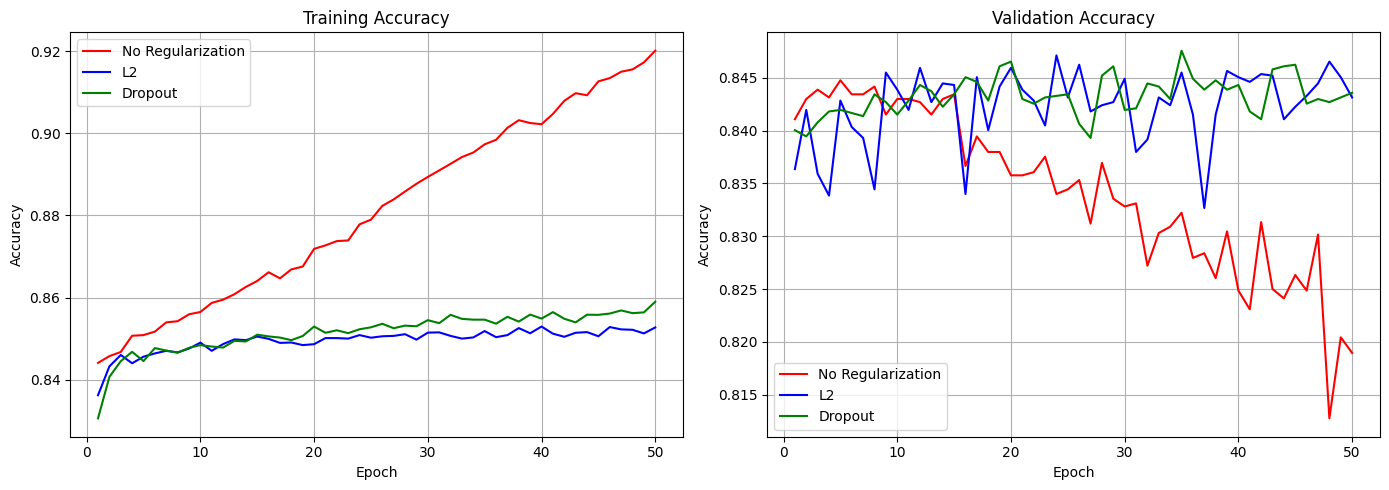

In [37]:
epochs = range(1, 51)

plt.figure(figsize=(14, 5))

# --- Training Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_no_reg.history['accuracy'], label='No Regularization', color='red')
plt.plot(epochs, history_l2.history['accuracy'],     label='L2',               color='blue')
plt.plot(epochs, history_dropout.history['accuracy'],label='Dropout',          color='green')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_no_reg.history['val_accuracy'], label='No Regularization', color='red')
plt.plot(epochs, history_l2.history['val_accuracy'],     label='L2',               color='blue')
plt.plot(epochs, history_dropout.history['val_accuracy'],label='Dropout',          color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# Evaluate each model on the test set
_, acc_no_reg  = model_no_reg.evaluate(X_test,  y_test, verbose=0)
_, acc_l2      = model_l2.evaluate(X_test,      y_test, verbose=0)
_, acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)

# Get final train and val accuracy from history
train_no_reg  = history_no_reg.history['accuracy'][-1]
train_l2      = history_l2.history['accuracy'][-1]
train_dropout = history_dropout.history['accuracy'][-1]

val_no_reg  = history_no_reg.history['val_accuracy'][-1]
val_l2      = history_l2.history['val_accuracy'][-1]
val_dropout = history_dropout.history['val_accuracy'][-1]

gap_no_reg  = train_no_reg  - val_no_reg
gap_l2      = train_l2      - val_l2
gap_dropout = train_dropout - val_dropout

# Print summary table
print("=" * 70)
print(f"{'Method':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Gap':>10}")
print("=" * 70)
print(f"{'No Regularization':<20} {train_no_reg:>8.4f} {val_no_reg:>8.4f} {acc_no_reg:>8.4f} {gap_no_reg:>10.4f}")
print(f"{'L2':<20} {train_l2:>8.4f} {val_l2:>8.4f} {acc_l2:>8.4f} {gap_l2:>10.4f}")
print(f"{'Dropout':<20} {train_dropout:>8.4f} {val_dropout:>8.4f} {acc_dropout:>8.4f} {gap_dropout:>10.4f}")
print("=" * 70)
print()
print("Gap = Train - Val  →  closer to 0 means less overfitting")

Method                  Train      Val     Test        Gap
No Regularization      0.9201   0.8190   0.8331     0.1011
L2                     0.8528   0.8431   0.8458     0.0096
Dropout                0.8590   0.8436   0.8485     0.0154

Gap = Train - Val  →  closer to 0 means less overfitting


|       | No Reg   | L2      | Dropout       |
| ----- | -------- | ------- | ------------- |
| Train | 92%      | 85.3%   | 85.9%         |
| Val   | 81.9%    | 84.3%   | 84.4%         |
| Test  | 83.3%    | 84.6%   | 84.9%  best |
| Gap   |  10.1% |  0.96% |  1.54%       |

**Do you see signs of overfitting?**

Yes — No Reg model has a 10.1% gap between train and val. Train keeps rising to 92% while val drops to 81.9%.

**Which regularization was more effective?**

Both worked well but:

L2 gave the smallest gap (0.96%) → better at controlling overfitting

Dropout gave the best test accuracy (84.9%) → better at generalizing to new data

Overall Dropout wins on real-world performance



---



## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

### Without Early Stopping

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model_no_es = build_model()

history_no_es = model_no_es.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Training without Early Stopping done — 50 epochs")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8128 - loss: 0.4028 - val_accuracy: 0.8393 - val_loss: 0.3385
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8443 - loss: 0.3310 - val_accuracy: 0.8417 - val_loss: 0.3362
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8476 - loss: 0.3288 - val_accuracy: 0.8395 - val_loss: 0.3374
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8484 - loss: 0.3248 - val_accuracy: 0.8414 - val_loss: 0.3303
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8484 - loss: 0.3256 - val_accuracy: 0.8449 - val_loss: 0.3302
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8542 - loss: 0.3146 - val_accuracy: 0.8442 - val_loss: 0.3300
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8522 - loss: 0.3149 - val_accuracy: 0.8428 - val_loss: 0.3302
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8504 - loss: 0.3200 - val_accuracy: 0.

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

model_es = build_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_es = model_es.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

stopped_epoch = len(history_es.history['loss'])
print(f"\n Early Stopping triggered at epoch: {stopped_epoch}")
print(f"Best val_loss was around epoch {stopped_epoch - 10}")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8154 - loss: 0.4004 - val_accuracy: 0.8399 - val_loss: 0.3399
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8455 - loss: 0.3347 - val_accuracy: 0.8433 - val_loss: 0.3366
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8439 - loss: 0.3284 - val_accuracy: 0.8421 - val_loss: 0.3343
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8522 - loss: 0.3198 - val_accuracy: 0.8412 - val_loss: 0.3325
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8517 - loss: 0.3168 - val_accuracy: 0.8431 - val_loss: 0.3302
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8481 - loss: 0.3211 - val_accuracy: 0.8443 - val_loss: 0.3312
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8505 - loss: 0.3203 - val_accuracy: 0.8440 - val_loss: 0.3282
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8493 - loss: 0.3184 - val_accuracy: 0.

### Comparison

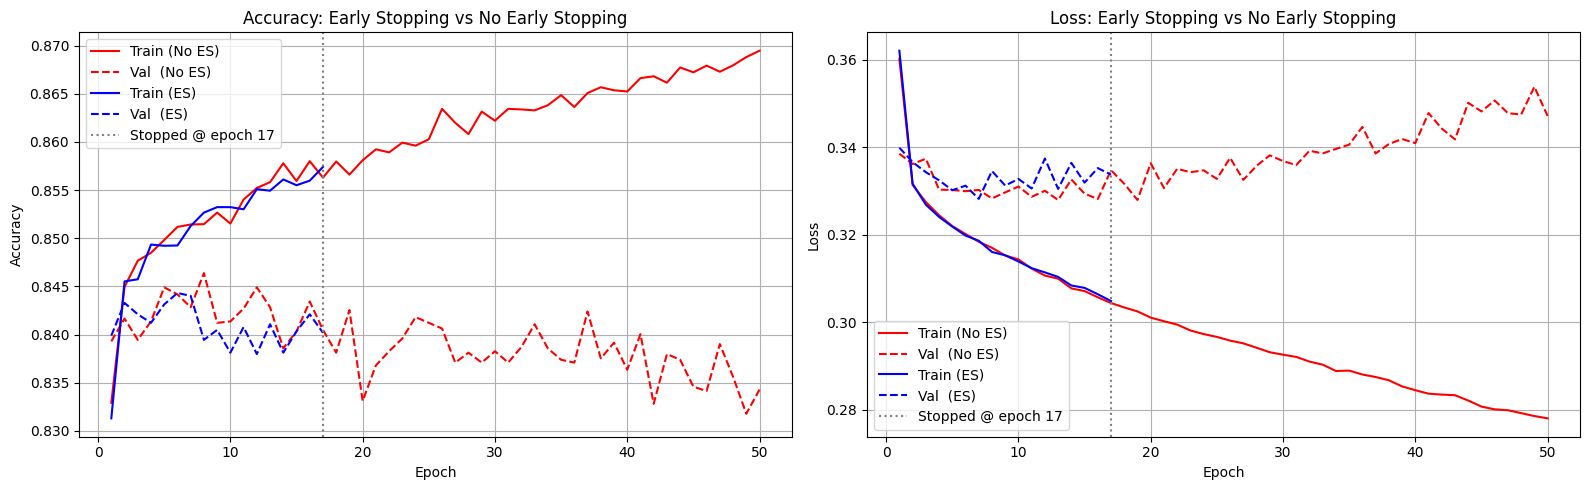

In [43]:
import matplotlib.pyplot as plt

epochs_no_es = range(1, 51)
epochs_es    = range(1, 18)  # stopped at 17

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Accuracy ---
axes[0].plot(epochs_no_es, history_no_es.history['accuracy'],     'r-',  label='Train (No ES)')
axes[0].plot(epochs_no_es, history_no_es.history['val_accuracy'], 'r--', label='Val  (No ES)')
axes[0].plot(epochs_es,    history_es.history['accuracy'],        'b-',  label='Train (ES)')
axes[0].plot(epochs_es,    history_es.history['val_accuracy'],    'b--', label='Val  (ES)')
axes[0].axvline(17, color='gray', linestyle=':', label='Stopped @ epoch 17')
axes[0].set_title('Accuracy: Early Stopping vs No Early Stopping')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss ---
axes[1].plot(epochs_no_es, history_no_es.history['loss'],     'r-',  label='Train (No ES)')
axes[1].plot(epochs_no_es, history_no_es.history['val_loss'], 'r--', label='Val  (No ES)')
axes[1].plot(epochs_es,    history_es.history['loss'],        'b-',  label='Train (ES)')
axes[1].plot(epochs_es,    history_es.history['val_loss'],    'b--', label='Val  (ES)')
axes[1].axvline(17, color='gray', linestyle=':', label='Stopped @ epoch 17')
axes[1].set_title('Loss: Early Stopping vs No Early Stopping')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('early_stopping_curves.png', dpi=150)
plt.show()

In [44]:
_, test_no_es = model_no_es.evaluate(X_test, y_test, verbose=0)
_, test_es    = model_es.evaluate(X_test,    y_test, verbose=0)

val_no_es_final = history_no_es.history['val_accuracy'][-1]
val_es_final    = history_es.history['val_accuracy'][-1]

print("=" * 55)
print(f"{'Method':<25} {'Epochs':>6} {'Val Acc':>10} {'Test Acc':>10}")
print("=" * 55)
print(f"{'No Early Stopping':<25} {50:>6} {val_no_es_final:>10.4f} {test_no_es:>10.4f}")
print(f"{'Early Stopping':<25} {17:>6} {val_es_final:>10.4f} {test_es:>10.4f}")
print("=" * 55)

Method                    Epochs    Val Acc   Test Acc
No Early Stopping             50     0.8343     0.8414
Early Stopping                17     0.8402     0.8452


|                | No Early Stopping | Early Stopping |
| -------------- | ----------------- | -------------- |
| Epochs Trained | 50                | 17  (66% less) |
| Val Accuracy   | 83.43%            | 84.02%       |
| Test Accuracy  | 84.14%            | 84.52%       |

**Compare epochs trained and final accuracy:**

Early Stopping used only 17 epochs instead of 50, yet achieved better val (+0.6%) and test (+0.4%) accuracy — proving that training longer without control actively hurts performance.

**How does Early Stopping prevent overfitting?**

Monitors val_loss every epoch — the true signal of generalization

Stops training when val_loss stops improving for patience=10 epochs

Restores best weights automatically — you always get the peak model, not the last one

Acts as a free regularizer — no extra parameters, no architecture changes needed

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

**What I Learned**

**🔧 Role of Optimizers**
Optimizers control how the model updates its weights during training. Adam consistently outperformed SGD and RMSprop because it combines momentum and adaptive learning rates, making it faster to converge and more stable. SGD was slowest but most predictable. The choice of optimizer directly affects both training speed and final accuracy.

**📦 Effect of Batch Size**
Smaller batch sizes (e.g., 16) introduce more noise into updates, which can help escape local minima but slow training significantly. Larger batches (e.g., 256) are faster but tend to converge to sharper minima, sometimes hurting generalization. Batch size 32 struck the best balance between speed and validation accuracy in our experiments.

**🛡️ Regularization Methods**
Without regularization, the model memorized training data — train accuracy hit 92% while val accuracy dropped to 81.9%, a 10% gap. Both L2 and Dropout reduced this gap to under 2%. L2 penalizes large weights directly, while Dropout forces the network to learn redundant representations. Dropout gave slightly better test accuracy (84.9%) while L2 was more stable and less noisy.

**⏹️ Early Stopping**
Early stopping proved to be a powerful and free regularizer. Without it, the model trained for 50 useless epochs and degraded val accuracy. With it, training stopped at epoch 17, restored the best weights from epoch 7, and achieved better val and test accuracy with 66% less training time. The key insight: more epochs ≠ better model.

**✂️ Train/Validation/Test Splits**
The three-way split serves three distinct purposes — training teaches the model, validation guides decisions (hyperparameters, early stopping), and test gives an unbiased final estimate. Using val data for decisions and test data for final evaluation ensures no data leakage and honest reporting.

**🧠 My Choices for a New Tabular Dataset**

| Decision       | My Choice                                                       | Why                                                                      |
| -------------- | --------------------------------------------------------------- | ------------------------------------------------------------------------ |
| Optimizer      | Adam                                                            | Fastest convergence, handles sparse gradients, works well out-of-the-box |
| Batch Size     | 32                                                              | Best balance between training speed and generalization                   |
| Regularization | Dropout (0.3–0.5)                                               | Better test accuracy, forces robust features, easy to tune               |
| Early Stopping | ✅ Yes, patience=10, monitor=val_loss, restore_best_weights=True | Free regularizer, saves time, always returns best model                  |
| Data Split     | 70% Train / 15% Val / 15% Test                                  | Enough data to train, enough to validate and evaluate fairly             |

**Overall strategy:** Start with Adam + batch 32 + Dropout + Early Stopping as the default baseline. This combination proved consistently strong across all our experiments and requires minimal tuning to achieve good generalization.